# Ex4.5 Shape-Threshold Sensitivity at 5% Noise

This notebook studies the remaining Algorithm-3 thresholds $t_{AR}$ and $t_{CV}$ after removing the curvature-based shape criterion.


In [14]:
from importlib import reload
import torch
import numpy as np
import time
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import sys
sys.path.append(r"../main_code/2d")
import generate_data, mesh, adaptive_int, visual, matrix_assemble, inverse_solver, mea_2d, net_2d, source_eval, error_general_2d, main, bound_detect
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    r_y = np.linalg.norm(x - center, axis=-1)
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r):
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:4


In [15]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4
nx,ny=3,3
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5

num_batches_gauss=1
b_n=10
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n)
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_05 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_05 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_05 = -F_mea_db_x21 + F_mea_db_x22
F_05=inverse_solver.F(F_mea_b_05,F_mea_db_x1_05,F_mea_db_x2_05)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b)
initial_cells=copy.deepcopy(cells)
R_m=20


In [16]:
M=1600
af="Tanh"
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
models = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
loaded_model = torch.load("./Noise/noise=5%/models0_33_1600_7056_0.0009999999999999998.pth", map_location="cpu")[0][0]
models[0][0].load_state_dict(loaded_model.state_dict())
models = models[0][0].double().to(device)
with open("./Noise/noise=5%/cells_store_last.pkl", "rb") as f:
    cells_store_last = pickle.load(f)
g_S=np.load("./Noise/noise=5%/g_S.npy")
S_num_store=np.load("./Noise/noise=5%/S_num_store.npy")

x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)


In [ ]:
para_abs=3.0
para_grad=3.0
c_eps=5.0
mini_samples=20

t_reg_center = 0.05
t_cv_center = 0.70
perturbation_factor = np.array([0.8, 1.0, 1.2])

t_reg_values = np.round(t_reg_center * perturbation_factor, 3)
t_cv_values = np.round(t_cv_center * perturbation_factor, 3)

threshold_results={}
cluster_count={}
shape_summary={}

for i, t_reg in enumerate(t_reg_values):
    for j, t_cv in enumerate(t_cv_values):
        fig_tmp, ax_tmp = plt.subplots(figsize=(4,4))
        detected = bound_detect.detect_shape(
            g_S, X.T, Y.T,
            tau_x_min, tau_x_max, tau_y_min, tau_y_max,
            para_abs, para_grad, c_eps, mini_samples,
            S_num_store[-1],
            ax=ax_tmp,
            fig=fig_tmp,
            output_directory="./Noise/noise=5%/shape_threshold_sensitivity",
            output_filename=f"shape_threshold_treg_{i}_tcv_{j}.png",
            show_colorbar=False,
            eps_mode="grid_scaled",
            min_cluster_size=200,
            min_relative_abs_s=0.2,
            min_relative_grad=0.25,
            keep_top_k=None,
            residual_threshold=float(t_reg),
            t_cv=float(t_cv),
        )
        plt.close(fig_tmp)
        threshold_results[(i, j)] = {
            'params': {
                't_reg': float(t_reg),
                't_cv': float(t_cv),
            },
            'detected': detected,
        }
        cluster_count[(i, j)] = len(detected)
        shape_summary[(i, j)] = '+'.join(sorted(item['shape'] for item in detected))
        print(
            f"(i={i}, j={j}) "
            f"treg={t_reg:.3f}, "
            f"tCV={t_cv:.3f} "
            f"-> clusters={cluster_count[(i, j)]}, shapes={shape_summary[(i, j)]}"
        )


DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.92
  Res_Rect=0.032863 vs Res_Ellip=0.122733
  center=(0.3894, 0.4998)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.243
Cluster 1: AR=1.00
  Res_Rect=0.093626 vs Res_Ellip=0.012096
  center=(0.7098, 0.4996)
  -> Decision: Ellipsoid (Sigmoid)
(i=0, j=0) tREG=0.040, tCV=0.560 -> clusters=2, shapes=Ellipsoid+Rectangle
DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.92
  Res_Rect=0.032863 vs Res_Ellip=0.122733
  center=(0.3894, 0.4998)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.243
Cluster 1: AR=1.00
  Res_Rect=0.093626 vs Res_Ellip=0.012096
  center=(0.7098, 0.4996)
  -> Decision: Ellipsoid (Sigmoid)
(i=0, j=1) tREG=0.040, tCV=0.700 -> clusters=2, shapes=Ellipsoid+Rectangle
DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
N

/home/hxw-b25/.conda/envs/MLPDE/lib/python3.10/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


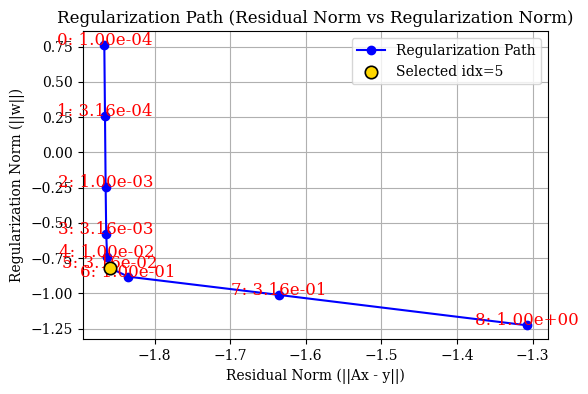

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.509481e-01
  idx=5, lambda=3.162278e-02, curvature=4.886686e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.447136e-01
(i=0, j=0) candidate idx: [4 5 6]
(i=0, j=0) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.602669949640345 S_L_2= 0.06895242565329036 S_l_2= 0.15266160096082318
(i=0, j=0) candidate idx=4, lamb=0.0001, S_l_inf=1.602669949640345, S_l_2=0.15266160096082318
S_l_inf= 1.6457590800071773 S_L_2= 0.07081125612025156 S_l_2= 0.15677707670097954
(i=0, j=0) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.6457590800071773, S_l_2=0.15677707670097954
S_l_inf= 1.6624301088125926 S_L_2= 0.07369992812370571 S_l_2= 0.1631726355014113
(i=0, j=0) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6624301088125926, S_l_2=0.1631726355014113
(i=0, j=0) picked idx: 4
(i=0, j=0) picked lambda: 0.0001


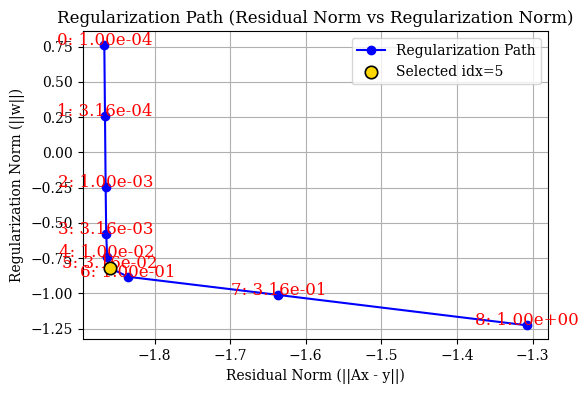

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.492746e-01
  idx=5, lambda=3.162278e-02, curvature=4.776889e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.590405e-01
(i=0, j=1) candidate idx: [4 5 6]
(i=0, j=1) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.591751841879527 S_L_2= 0.06963021116402356 S_l_2= 0.15416222722880774
(i=0, j=1) candidate idx=4, lamb=0.0001, S_l_inf=1.591751841879527, S_l_2=0.15416222722880774
S_l_inf= 1.6072847214328805 S_L_2= 0.07098832822476969 S_l_2= 0.15716911673010286
(i=0, j=1) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.6072847214328805, S_l_2=0.15716911673010286
S_l_inf= 1.6199273833180137 S_L_2= 0.0736046824599252 S_l_2= 0.16296176031638995
(i=0, j=1) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6199273833180137, S_l_2=0.16296176031638995
(i=0, j=1) picked idx: 4
(i=0, j=1) picked lambda: 0.0001


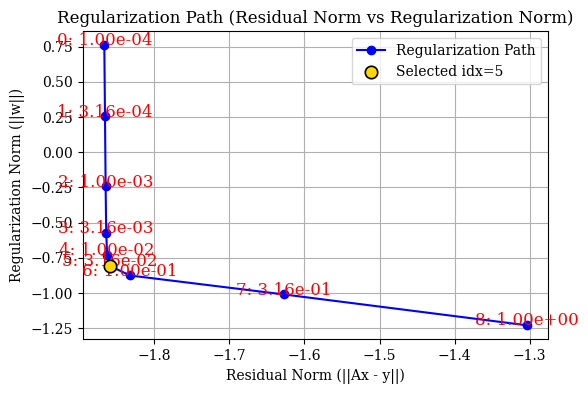

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.857093e-01
  idx=5, lambda=3.162278e-02, curvature=4.490246e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=7.857018e-01
(i=0, j=2) candidate idx: [4 5 6]
(i=0, j=2) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.499270882647786 S_L_2= 0.0690611204632968 S_l_2= 0.15290225273709498
(i=0, j=2) candidate idx=4, lamb=0.0001, S_l_inf=1.499270882647786, S_l_2=0.15290225273709498
S_l_inf= 1.5171167462903274 S_L_2= 0.07067742553689335 S_l_2= 0.15648077398328086
(i=0, j=2) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.5171167462903274, S_l_2=0.15648077398328086
S_l_inf= 1.5260622045742975 S_L_2= 0.07348697197107214 S_l_2= 0.1627011477054784
(i=0, j=2) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5260622045742975, S_l_2=0.1627011477054784
(i=0, j=2) picked idx: 4
(i=0, j=2) picked lambda: 0.0001


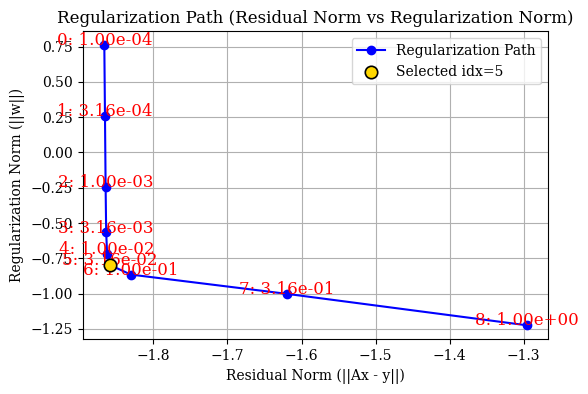

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=3.055545e-01
  idx=5, lambda=3.162278e-02, curvature=4.644678e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=7.187132e-01
(i=1, j=0) candidate idx: [4 5 6]
(i=1, j=0) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.6564933793253802 S_L_2= 0.07038772327274519 S_l_2= 0.1558393692607086
(i=1, j=0) candidate idx=4, lamb=0.0001, S_l_inf=1.6564933793253802, S_l_2=0.1558393692607086
S_l_inf= 1.6275497433495656 S_L_2= 0.07243608348969616 S_l_2= 0.1603744664251877
(i=1, j=0) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.6275497433495656, S_l_2=0.1603744664251877
S_l_inf= 1.6030957542310271 S_L_2= 0.07561736874572145 S_l_2= 0.1674178749158462
(i=1, j=0) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6030957542310271, S_l_2=0.1674178749158462
(i=1, j=0) picked idx: 4
(i=1, j=0) picked lambda: 0.0001


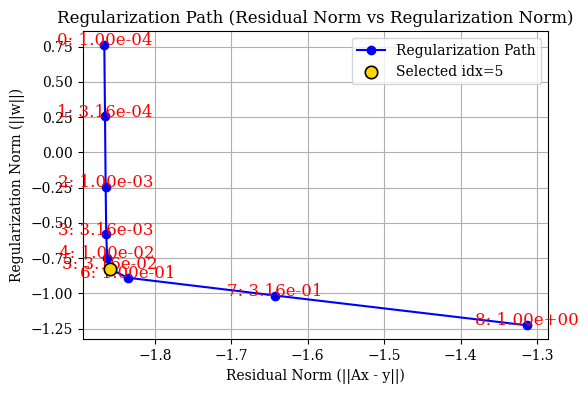

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.299862e-01
  idx=5, lambda=3.162278e-02, curvature=4.592025e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=9.385909e-01
(i=1, j=1) candidate idx: [4 5 6]
(i=1, j=1) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.5440565114675724 S_L_2= 0.06917505772854367 S_l_2= 0.15315451138001998
(i=1, j=1) candidate idx=4, lamb=0.0001, S_l_inf=1.5440565114675724, S_l_2=0.15315451138001998
S_l_inf= 1.546539797034244 S_L_2= 0.07089626322188607 S_l_2= 0.1569652835712326
(i=1, j=1) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.546539797034244, S_l_2=0.1569652835712326
S_l_inf= 1.5499965017087811 S_L_2= 0.07381196841596048 S_l_2= 0.16342069422053074
(i=1, j=1) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5499965017087811, S_l_2=0.16342069422053074
(i=1, j=1) picked idx: 4
(i=1, j=1) picked lambda: 0.0001


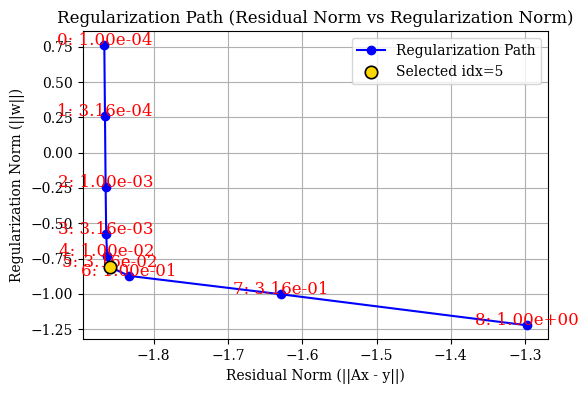

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.713255e-01
  idx=5, lambda=3.162278e-02, curvature=4.941601e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=7.919431e-01
(i=1, j=2) candidate idx: [4 5 6]
(i=1, j=2) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.462399967316929 S_L_2= 0.06825493968428442 S_l_2= 0.1511173576123504
(i=1, j=2) candidate idx=4, lamb=0.0001, S_l_inf=1.462399967316929, S_l_2=0.1511173576123504
S_l_inf= 1.4910371429571614 S_L_2= 0.06998609813016 S_l_2= 0.154950165774794
(i=1, j=2) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.4910371429571614, S_l_2=0.154950165774794
S_l_inf= 1.5078294373512438 S_L_2= 0.07310216129142287 S_l_2= 0.16184917166742763
(i=1, j=2) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5078294373512438, S_l_2=0.16184917166742763
(i=1, j=2) picked idx: 4
(i=1, j=2) picked lambda: 0.0001


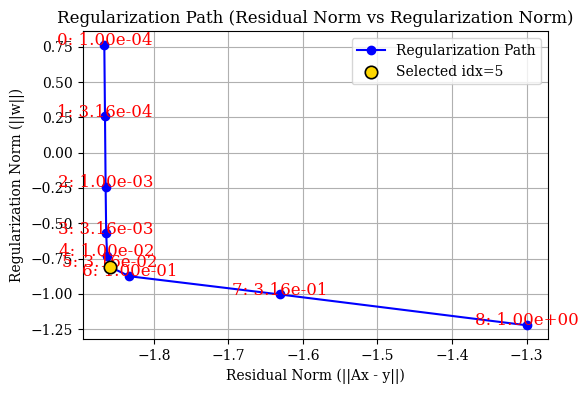

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.725098e-01
  idx=5, lambda=3.162278e-02, curvature=4.447023e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.447511e-01
(i=2, j=0) candidate idx: [4 5 6]
(i=2, j=0) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.4708276957260227 S_L_2= 0.0687004656941928 S_l_2= 0.1521037582109935
(i=2, j=0) candidate idx=4, lamb=0.0001, S_l_inf=1.4708276957260227, S_l_2=0.1521037582109935
S_l_inf= 1.5430195905663957 S_L_2= 0.07063077510021218 S_l_2= 0.1563774892868863
(i=2, j=0) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.5430195905663957, S_l_2=0.1563774892868863
S_l_inf= 1.6091124014118812 S_L_2= 0.07390521377199302 S_l_2= 0.16362714069720244
(i=2, j=0) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6091124014118812, S_l_2=0.16362714069720244
(i=2, j=0) picked idx: 4
(i=2, j=0) picked lambda: 0.0001


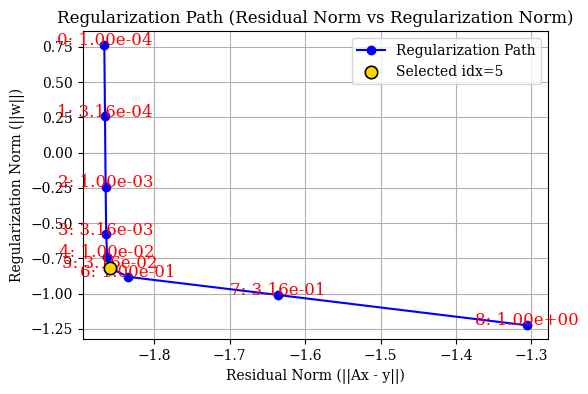

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.566573e-01
  idx=5, lambda=3.162278e-02, curvature=4.832546e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.589626e-01
(i=2, j=1) candidate idx: [4 5 6]
(i=2, j=1) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.5493586983829626 S_L_2= 0.06798444542477194 S_l_2= 0.15051847967126789
(i=2, j=1) candidate idx=4, lamb=0.0001, S_l_inf=1.5493586983829626, S_l_2=0.15051847967126789
S_l_inf= 1.557138229682279 S_L_2= 0.06975859350046928 S_l_2= 0.154446467454314
(i=2, j=1) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.557138229682279, S_l_2=0.154446467454314
S_l_inf= 1.5634498151281095 S_L_2= 0.07274533151364095 S_l_2= 0.16105914572373434
(i=2, j=1) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.5634498151281095, S_l_2=0.16105914572373434
(i=2, j=1) picked idx: 4
(i=2, j=1) picked lambda: 0.0001


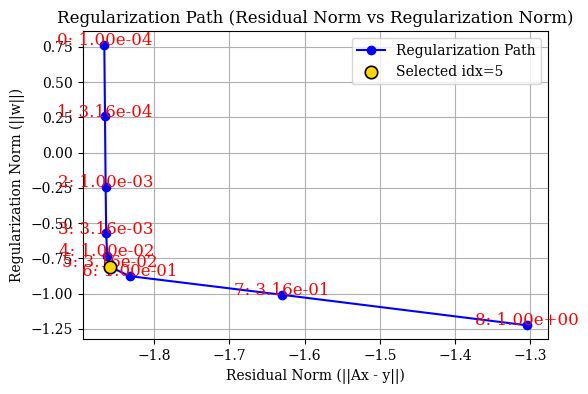

L-curve corner index: 5
Curvature-centered lambda window:
  idx=4, lambda=1.000000e-02, curvature=2.724020e-01
  idx=5, lambda=3.162278e-02, curvature=4.546610e+00 <== center
  idx=6, lambda=1.000000e-01, curvature=8.167388e-01
(i=2, j=2) candidate idx: [4 5 6]
(i=2, j=2) candidate lambda: [0.0001, 0.0009999999999999998, 0.010000000000000002]
S_l_inf= 1.589281592198901 S_L_2= 0.06899413944399602 S_l_2= 0.15275395585640422
(i=2, j=2) candidate idx=4, lamb=0.0001, S_l_inf=1.589281592198901, S_l_2=0.15275395585640422
S_l_inf= 1.6177230978464865 S_L_2= 0.0708681393421804 S_l_2= 0.15690301692201153
(i=2, j=2) candidate idx=5, lamb=0.0009999999999999998, S_l_inf=1.6177230978464865, S_l_2=0.15690301692201153
S_l_inf= 1.6249440641377386 S_L_2= 0.07399142068117551 S_l_2= 0.16381800395755902
(i=2, j=2) candidate idx=6, lamb=0.010000000000000002, S_l_inf=1.6249440641377386, S_l_2=0.16381800395755902
(i=2, j=2) picked idx: 4
(i=2, j=2) picked lambda: 0.0001


In [ ]:

Qx,Qy=150,150
M_ellip=800
M_rec=800
lamb_regu=np.logspace(-4,0,9,endpoint=True)
reload(inverse_solver)
reload(error_general_2d)
reload(net_2d)
reload(matrix_assemble)

S_l2={}
lambda_candidates={}
window_results_all={}
selected_idx={}
selected_lambda={}
selected_w={}

for i in range(len(t_reg_values)):
    for j in range(len(t_cv_values)):
        params = threshold_results[(i, j)]['params']
        current_results = threshold_results[(i, j)]['detected']
        t_reg = params['t_reg']
        t_cv = params['t_cv']

        rect_entry = next((item for item in current_results if item.get('shape') == 'Rectangle'), None)
        ellip_entry = next((item for item in current_results if item.get('shape') == 'Ellipsoid'), None)

        if rect_entry is None or ellip_entry is None:
            print(
                f"(i={i}, j={j}) "
                f"treg={t_reg:.3f}, tCV={t_cv:.3f} "
                "missing Rectangle/Ellipsoid detection; skip this pair."
            )
            S_l2[(i,j)] = np.nan
            lambda_candidates[(i,j)] = []
            window_results_all[(i,j)] = []
            selected_idx[(i,j)] = None
            selected_lambda[(i,j)] = np.nan
            selected_w[(i,j)] = None
            continue

        center1 = np.asarray(rect_entry['params']['center'])
        width = rect_entry['params']['W']
        height = rect_entry['params']['H']
        center2 = np.asarray(ellip_entry['params']['center'])
        a_ellip = float(ellip_entry['params'].get('a', ellip_entry['params'].get('radius')))
        b_ellip = float(ellip_entry['params'].get('b', ellip_entry['params'].get('radius')))

        theta_min, theta_max = -1e-12, 1e-12
        K_old_min = 1000
        K_old_max = 20000
        # Use the paper's 2D nondimensional K mapping:
        #   K_ellip = (a*b) * K_old, with semi-axes a and b.
        #   K_rec = sqrt((width/2)*(height/2)) * K_old = 0.5*sqrt(width*height) * K_old.
        ellip_char = a_ellip * b_ellip
        K_ellip_min = ellip_char * K_old_min
        K_ellip_max = ellip_char * K_old_max
        rect_char = 0.5 * np.sqrt(width * height)
        K_rec_min = rect_char * K_old_min
        K_rec_max = rect_char * K_old_max
        min_rec1,max_rec1,min_rec2,max_rec2=-center1[0]*(1+0.05),-center1[0]*(1-0.05),-center1[1]*(1+0.05),-center1[1]*(1-0.05)
        min_ellip1,max_ellip1=min(center2[0]*(1-0.05), center2[0]*(1+0.05)),max(center2[0]*(1-0.05), center2[0]*(1+0.05))
        min_ellip2,max_ellip2=min(center2[1]*(1-0.05), center2[1]*(1+0.05)),max(center2[1]*(1-0.05), center2[1]*(1+0.05))
        axis_a_min,axis_a_max=a_ellip*(1-0.1),a_ellip*(1+0.05)
        axis_b_min,axis_b_max=b_ellip*(1-0.1),b_ellip*(1+0.05)
        width_min,width_max=width*(1-0.1),width*(1+0.05)
        height_min,height_max=height*(1-0.1),height*(1+0.05)

        models0=models
        models1=net_2d.pre_define(Nx,Ny,M_ellip,R_m,'sigmoid',tau_x_min,tau_x_max,tau_y_min,tau_y_max,theta_min,theta_max,min_ellip1,max_ellip1,min_ellip2,max_ellip2,axis_a_min,axis_a_max,axis_b_min,axis_b_max,[],[],[],[],K_ellip_min, K_ellip_max, 'ellipsoid',device)
        models2=net_2d.pre_define(Nx,Ny,M_rec,R_m,'sigmoid',tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],min_rec1,max_rec1,min_rec2,max_rec2,width_min,width_max,height_min,height_max,[],[],[],[],K_rec_min, K_rec_max, 'rec',device)

        sum_mat,all_g_p1,all_g_n,cells_copy1 = matrix_assemble.mat_assemble2(
            cells_store_last,models0,models1,models2,'mix','ellipsoid','rec',kk,0,points_b,device,cupy_device
        )
        res,reg_norm,w_store = inverse_solver.L_curve(sum_mat,F_05,[],[],[],lamb_regu,'linear',device,cupy_device)
        window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
            lamb_regu, res, reg_norm, radius=1, w_store=w_store
        )

        lambda_candidates[(i,j)] = [float(val**2) for val in window_lambda]
        print(f"(i={i}, j={j}) candidate idx: {window_idx}")
        print(f"(i={i}, j={j}) candidate lambda: {lambda_candidates[(i,j)]}")

        window_results = []
        for local_i, cand_idx in enumerate(window_idx):
            cand_lamb = window_lambda[local_i]**2
            cand_w = window_w[:, local_i]
            result_tuple = error_general_2d.test(
                models0,models1,models2,[],Qx,Qy,cand_w,'mix','ellipsoid','rec',
                False,False,tau_x_min,tau_x_max,tau_y_min,tau_y_max,
                x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,0,device
            )
            window_results.append({
                'idx': int(cand_idx),
                'lambda': float(cand_lamb),
                'w': cand_w,
                'result': result_tuple,
            })
            print(
                f"(i={i}, j={j}) candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
                f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
            )

        window_results_all[(i,j)] = window_results
        pick = 0
        picked = window_results[pick]
        selected_idx[(i,j)] = picked['idx']
        selected_lambda[(i,j)] = picked['lambda']
        selected_w[(i,j)] = picked['w']
        S_l2[(i,j)] = picked['result'][3]
        print(f"(i={i}, j={j}) picked idx: {selected_idx[(i,j)]}")
        print(f"(i={i}, j={j}) picked lambda: {selected_lambda[(i,j)]}")

        del models1, models2, sum_mat, all_g_p1, all_g_n, cells_copy1, res, reg_norm, w_store, window_results
        if device.type == 'cuda':
            torch.cuda.empty_cache()


In [25]:

from collections import Counter

summary_records = []
for i, t_reg in enumerate(t_reg_values):
    for j, t_cv in enumerate(t_cv_values):
        key = (i, j)
        detected_items = threshold_results[key]['detected']
        profile_summary = '+'.join(
            sorted(f"{item.get('shape', '')}({item.get('profile', '')})" for item in detected_items)
        )
        record = {
            'i': int(i),
            'j': int(j),
            't_reg': float(t_reg),
            't_cv': float(t_cv),
            'cluster_count': int(cluster_count.get(key, 0)),
            'shape_summary': shape_summary.get(key, ''),
            'profile_summary': profile_summary,
            'selected_idx': selected_idx.get(key, None),
            'selected_lambda': float(selected_lambda.get(key, np.nan)),
            'S_l2': float(S_l2.get(key, np.nan)),
            'is_valid': bool(np.isfinite(S_l2.get(key, np.nan))),
        }
        summary_records.append(record)

cluster_distribution = Counter(record['cluster_count'] for record in summary_records)
shape_distribution = Counter(record['shape_summary'] for record in summary_records)
profile_distribution = Counter(record['profile_summary'] for record in summary_records)
shape_labels = sorted(shape_distribution.keys())
profile_labels = sorted(profile_distribution.keys())

print('Per-grid parameter / shape / profile / cluster summary:')
for record in summary_records:
    print(
        f"(i={record['i']}, j={record['j']}) "
        f"treg={record['t_reg']:.3f}, "
        f"tCV={record['t_cv']:.3f}, "
        f"-> shapes={record['shape_summary']}, "
        f"profiles={record['profile_summary']}, "
        f"clusters={record['cluster_count']}, "
        f"valid={record['is_valid']}, "
        f"lambda={record['selected_lambda']:.6e}, "
        f"S_l2={record['S_l2']:.6e}"
    )

print('\nCluster-count distribution:')
for key in sorted(cluster_distribution):
    print(f"clusters={key}: {cluster_distribution[key]} runs")

print('\nShape-summary distribution:')
for key in shape_labels:
    print(f"{key}: {shape_distribution[key]} runs")

print('\nProfile-summary distribution:')
for key in profile_labels:
    print(f"{key}: {profile_distribution[key]} runs")


Per-grid parameter / shape / profile / cluster summary:
(i=0, j=0) treg=0.040, tCV=0.560, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.526616e-01
(i=0, j=1) treg=0.040, tCV=0.700, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.541622e-01
(i=0, j=2) treg=0.040, tCV=0.840, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.529023e-01
(i=1, j=0) treg=0.050, tCV=0.560, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.558394e-01
(i=1, j=1) treg=0.050, tCV=0.700, -> shapes=Ellipsoid+Rectangle, profiles=Ellipsoid(Sigmoid)+Rectangle(Sigmoid), clusters=2, valid=True, lambda=1.000000e-04, S_l2=1.531545e-01
(i=1, j=2) treg=0.050, tCV=0.840, -> shapes=Ellipsoid+Rectangle,

In [26]:

with open('./Noise/noise=5%/shape_threshold_sensitivity_results.pkl', 'wb') as f:
    pickle.dump(
        {
            't_reg_center': t_reg_center,
            't_cv_center': t_cv_center,
            'perturbation_factor': perturbation_factor,
            't_reg_values': t_reg_values,
            't_cv_values': t_cv_values,
            'cluster_count': cluster_count,
            'shape_summary': shape_summary,
            'threshold_results': threshold_results,
            'S_l2': S_l2,
            'selected_idx': selected_idx,
            'selected_lambda': selected_lambda,
            'lambda_candidates': lambda_candidates,
            'summary_records': summary_records,
            'cluster_distribution': dict(cluster_distribution),
            'shape_distribution': dict(shape_distribution),
            'profile_distribution': dict(profile_distribution),
        },
        f,
    )


,i,j,t_reg,t_cv,shape_summary,profile_summary,cluster_count,selected_idx,selected_lambda,S_l2,is_valid
0,0,0,0.04,0.56,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.527e-01,True
1,0,1,0.04,0.70,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.542e-01,True
2,0,2,0.04,0.84,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.529e-01,True
3,1,0,0.05,0.56,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.558e-01,True
4,1,1,0.05,0.70,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.532e-01,True
5,1,2,0.05,0.84,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.511e-01,True
6,2,0,0.06,0.56,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.521e-01,True
7,2,1,0.06,0.70,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.505e-01,True
8,2,2,0.06,0.84,Ellipsoid+Rectangle,Ellipsoid(Sigmoid)+Rectangle(Sigmoid),2,4,1.000e-04,1.528e-01,True


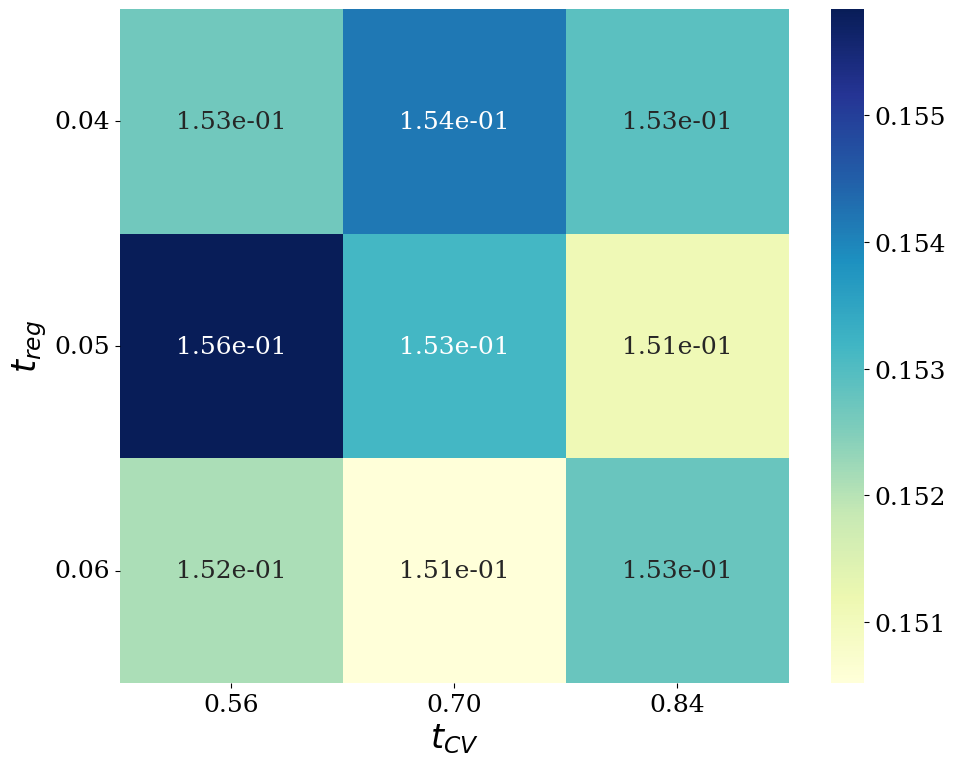

In [27]:

import pandas as pd
from IPython.display import display
import seaborn as sns

summary_df = pd.DataFrame(summary_records)
summary_df = summary_df[[
    'i',
    'j',
    't_reg',
    't_cv',
    'shape_summary',
    'profile_summary',
    'cluster_count',
    'selected_idx',
    'selected_lambda',
    'S_l2',
    'is_valid',
]].copy()
summary_df = summary_df.sort_values(['i', 'j']).reset_index(drop=True)
summary_df[['t_reg', 't_cv']] = summary_df[['t_reg', 't_cv']].round(3)
summary_df['selected_lambda'] = summary_df['selected_lambda'].map(lambda v: f"{v:.3e}" if np.isfinite(v) else 'nan')
summary_df['S_l2'] = summary_df['S_l2'].map(lambda v: f"{v:.3e}" if np.isfinite(v) else 'nan')

display(summary_df)
summary_df.to_csv('./Noise/noise=5%/shape_threshold_sensitivity_summary.csv', index=False)

heatmap_data = np.array([
    [S_l2[(i, j)] for j in range(len(t_cv_values))]
    for i in range(len(t_reg_values))
])

plt.figure(figsize=(10, 8))
plt.rcParams['font.size'] = 18
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2e',
    cmap='YlGnBu',
    xticklabels=[f"{val:.2f}" for val in t_cv_values],
    yticklabels=[f"{val:.2f}" for val in t_reg_values],
)
ax.collections[0].colorbar.ax.tick_params(labelsize=18)

plt.xlabel(r'$t_{CV}$', fontsize=24)
plt.ylabel(r'$t_{reg}$', fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('./Noise/noise=5%/shape_threshold_sensitivity_heatmap.pdf', dpi=300)
plt.show()
